#Prashna Prajapati
#2438462

# Part III - Language Tasks  

Dataset: Sarcastic Headlines Dataset  Classes:  
- `0` = Not Sarcastic  
- `1` = Sarcastic


#Text Preprocessing, Tokenization, and Sequence Padding

## Install Required Library

In [ ]:
!pip install contractions
!pip install gensim
!pip install gradio

## Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import re
import contractions
import nltk
import matplotlib.pyplot as plt
import time

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

import tensorflow as tf
import gensim.downloader as api

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Input, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

## Download NLTK Resources

In [ ]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

## Load Dataset

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Part- III- Language Tasks/sarcastic_headlines.csv")

print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

                                            headline  is_sarcastic
0  thirtysomething scientists unveil doomsday clo...             1
1  dem rep. totally nails why congress is falling...             0
2  eat your veggies: 9 deliciously different recipes             0
3  inclement weather prevents liar from getting t...             1
4  mother comes pretty close to using word 'strea...             1

Dataset Shape:
(28619, 2)

Columns:
Index(['headline', 'is_sarcastic'], dtype='object')

Missing Values:
headline        0
is_sarcastic    0
dtype: int64


## Text Cleaning Function

In [ ]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()

    text = contractions.fix(text)

    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    text = re.sub(r'@\w+|#\w+', '', text)

    text = re.sub(r'\d+', '', text)

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    words = text.split()

    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

df["clean_headline"] = df["headline"].apply(clean_text)

print("\nCleaned Headlines:")
df[["headline", "clean_headline"]].head()


Cleaned Headlines:


,headline,clean_headline
0,thirtysomething scientists unveil doomsday clo...,thirtysomething scientist unveil doomsday cloc...
1,dem rep. totally nails why congress is falling...,dem rep totally nail congress falling short ge...
2,eat your veggies: 9 deliciously different recipes,eat veggie deliciously different recipe
3,inclement weather prevents liar from getting t...,inclement weather prevents liar getting work
4,mother comes pretty close to using word 'strea...,mother come pretty close using word streaming ...


## Word Cloud Visualization

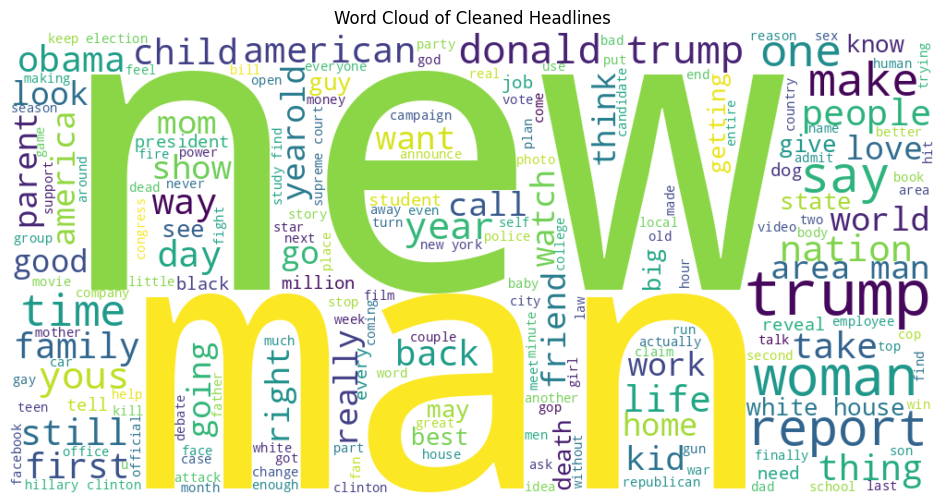

In [ ]:
all_words = " ".join(df["clean_headline"])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(all_words)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud of Cleaned Headlines")
plt.show()

## Most Frequent Words

In [ ]:
all_tokens = all_words.split()
word_freq = Counter(all_tokens)

print("\nMost Common Words:")
print(word_freq.most_common(20))


Most Common Words:
[('trump', 1794), ('new', 1677), ('man', 1507), ('woman', 884), ('say', 709), ('report', 691), ('get', 637), ('day', 589), ('one', 579), ('year', 558), ('time', 557), ('make', 544), ('american', 539), ('area', 503), ('donald', 475), ('like', 473), ('life', 453), ('yous', 452), ('first', 435), ('people', 429)]


## Train-Test Split

In [ ]:
X = df["clean_headline"]
y = df["is_sarcastic"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining Size:", len(X_train))
print("Testing Size:", len(X_test))


Training Size: 22895
Testing Size: 5724


## Tokenization

In [ ]:
tokenizer = Tokenizer(
    num_words=10000,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train)

X_train_sequences = tokenizer.texts_to_sequences(X_train)
X_test_sequences = tokenizer.texts_to_sequences(X_test)

word_index = tokenizer.word_index

print("\nVocabulary Size:", len(word_index))


Vocabulary Size: 22523


## Percentile-Based Padding

In [ ]:
sequence_lengths = [len(sequence) for sequence in X_train_sequences]

max_length = int(np.percentile(sequence_lengths, 95))

print("\nPadding Length:", max_length)

X_train_padded = pad_sequences(
    X_train_sequences,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

X_test_padded = pad_sequences(
    X_test_sequences,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

print("\nX_train_padded shape:")
print(X_train_padded.shape)

print("\nX_test_padded shape:")
print(X_test_padded.shape)


Padding Length: 11

X_train_padded shape:
(22895, 11)

X_test_padded shape:
(5724, 11)


# Model Building and Training

## Model Parameters and Early Stopping

In [ ]:
vocab_size = min(10000, len(word_index) + 1)
embedding_dim = 300
max_len = max_length

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

## Model 1: Simple RNN with Trainable Embedding Layer

In [ ]:
simple_rnn_model = Sequential([
    Input(shape=(max_len,)),

    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim
    ),

    SimpleRNN(64),

    Dropout(0.5),

    Dense(32, activation='relu'),

    Dense(1, activation='sigmoid')
])

simple_rnn_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

print("\nSimple RNN Model Summary:")
simple_rnn_model.summary()


Simple RNN Model Summary:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 11, 300)        │     3,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │        23,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,025,473 (11.54 MB)

 Trainable params: 3,025,473 (11.54 MB)

 Non-trainable params: 0 (0.00 B)

## Model 2: LSTM with Trainable Embedding Layer

In [ ]:
lstm_model = Sequential([
    Input(shape=(max_len,)),

    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim
    ),

    LSTM(64),

    Dropout(0.5),

    Dense(32, activation='relu'),

    Dense(1, activation='sigmoid')
])

lstm_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

print("\nLSTM Model Summary:")
lstm_model.summary()


LSTM Model Summary:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 11, 300)        │     3,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        93,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,095,553 (11.81 MB)

 Trainable params: 3,095,553 (11.81 MB)

 Non-trainable params: 0 (0.00 B)

## Model 3: LSTM with Pretrained Word2Vec Embeddings

In [ ]:
print("\nLoading Word2Vec Model...")
word2vec = api.load("word2vec-google-news-300")

embedding_matrix = np.random.normal(scale=0.1, size=(vocab_size, embedding_dim))

for word, index in word_index.items():
    if index < vocab_size:
        if word in word2vec:
            embedding_matrix[index] = word2vec[word]

print("\nEmbedding Matrix Shape:")
print(embedding_matrix.shape)


Loading Word2Vec Model...
[==================================================] 100.0% 1662.8/1662.8MB downloaded

Embedding Matrix Shape:
(10000, 300)


In [ ]:
word2vec_lstm_model = Sequential([
    Input(shape=(max_len,)),

    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        trainable=True
    ),

    LSTM(64),

    Dropout(0.5),

    Dense(32, activation='relu'),

    Dense(1, activation='sigmoid')
])

word2vec_lstm_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

print("\nLSTM + Word2Vec Model Summary:")
word2vec_lstm_model.summary()


LSTM + Word2Vec Model Summary:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 11, 300)        │     3,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        93,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,095,553 (11.81 MB)

 Trainable params: 3,095,553 (11.81 MB)

 Non-trainable params: 0 (0.00 B)

# Model Training and Evaluation

## Train All Models Once and Record Training Time

In [ ]:
def train_model(model, X_train_padded, y_train, model_name):
    start_time = time.time()

    history = model.fit(
        X_train_padded,
        y_train,
        validation_split=0.2,
        epochs=10,
        batch_size=32,
        callbacks=[early_stop]
    )

    training_time = time.time() - start_time

    print(f"\n{model_name} Training Time: {training_time:.2f} seconds")

    return history, training_time


history_rnn, rnn_time = train_model(
    simple_rnn_model,
    X_train_padded,
    y_train,
    "Simple RNN"
)

history_lstm, lstm_time = train_model(
    lstm_model,
    X_train_padded,
    y_train,
    "LSTM"
)

history_word2vec, word2vec_time = train_model(
    word2vec_lstm_model,
    X_train_padded,
    y_train,
    "Word2Vec + LSTM"
)

Epoch 1/10
573/573 ━━━━━━━━━━━━━━━━━━━━ 26s 38ms/step - accuracy: 0.7504 - loss: 0.5088 - val_accuracy: 0.8043 - val_loss: 0.4452
Epoch 2/10
573/573 ━━━━━━━━━━━━━━━━━━━━ 21s 37ms/step - accuracy: 0.9035 - loss: 0.2435 - val_accuracy: 0.7980 - val_loss: 0.4882
Epoch 3/10
573/573 ━━━━━━━━━━━━━━━━━━━━ 40s 36ms/step - accuracy: 0.9611 - loss: 0.1089 - val_accuracy: 0.7945 - val_loss: 0.5999
Epoch 4/10
573/573 ━━━━━━━━━━━━━━━━━━━━ 23s 40ms/step - accuracy: 0.9795 - loss: 0.0585 - val_accuracy: 0.7921 - val_loss: 0.7358

Simple RNN Training Time: 110.80 seconds
Epoch 1/10
573/573 ━━━━━━━━━━━━━━━━━━━━ 34s 54ms/step - accuracy: 0.7460 - loss: 0.5016 - val_accuracy: 0.7952 - val_loss: 0.4346
Epoch 2/10
573/573 ━━━━━━━━━━━━━━━━━━━━ 30s 52ms/step - accuracy: 0.8704 - loss: 0.3065 - val_accuracy: 0.7954 - val_loss: 0.4551
Epoch 3/10
573/573 ━━━━━━━━━━━━━━━━━━━━ 28s 50ms/step - accuracy: 0.9217 - loss: 0.1921 - val_accuracy: 0.7954 - val_loss: 0.5625
Epoch 4/10
573/573 ━━━━━━━━━━━━━━━━━━━━ 30s 52ms

## Evaluate Models

In [ ]:
rnn_loss, rnn_eval_accuracy = simple_rnn_model.evaluate(X_test_padded, y_test)
lstm_loss, lstm_eval_accuracy = lstm_model.evaluate(X_test_padded, y_test)
word2vec_loss, word2vec_eval_accuracy = word2vec_lstm_model.evaluate(X_test_padded, y_test)

print("\nSimple RNN Test Accuracy:", rnn_eval_accuracy)
print("LSTM Test Accuracy:", lstm_eval_accuracy)
print("Word2Vec + LSTM Test Accuracy:", word2vec_eval_accuracy)

179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7933 - loss: 0.4560
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7884 - loss: 0.4382
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8007 - loss: 0.4266

Simple RNN Test Accuracy: 0.7933263182640076
LSTM Test Accuracy: 0.7884346842765808
Word2Vec + LSTM Test Accuracy: 0.8006638884544373


## Plot Accuracy Curves

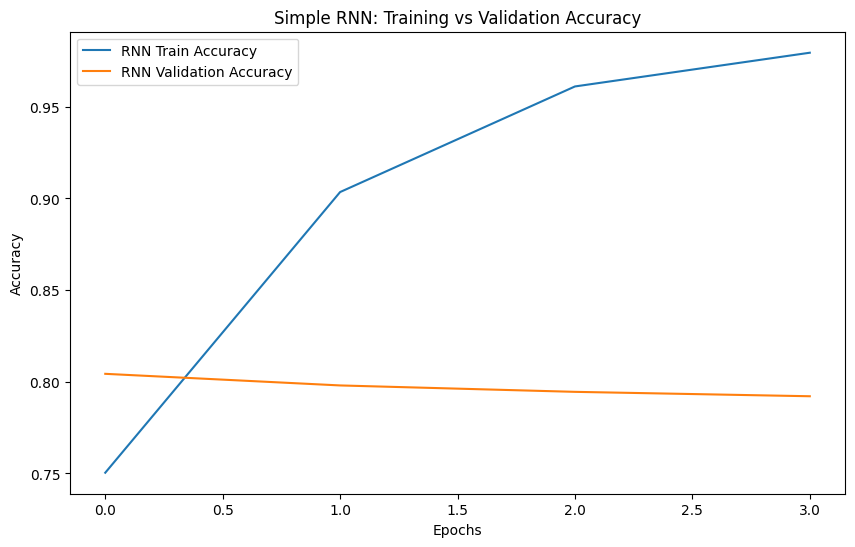

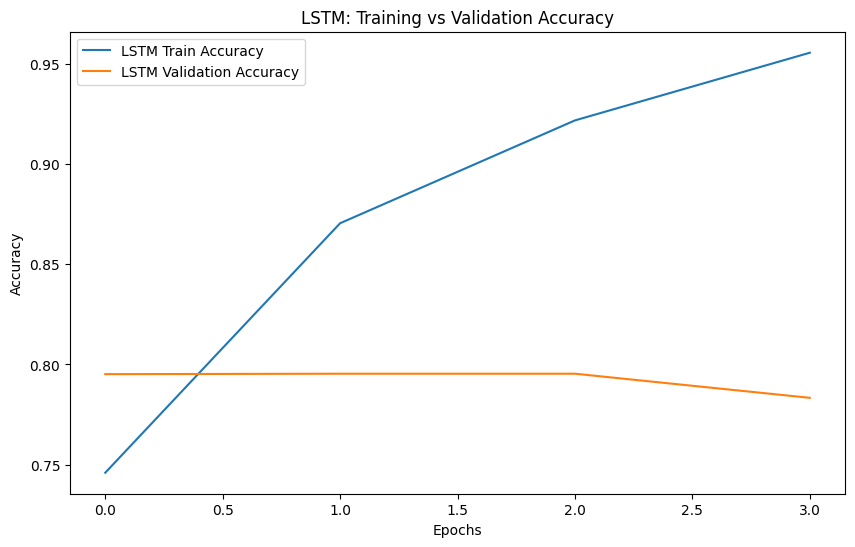

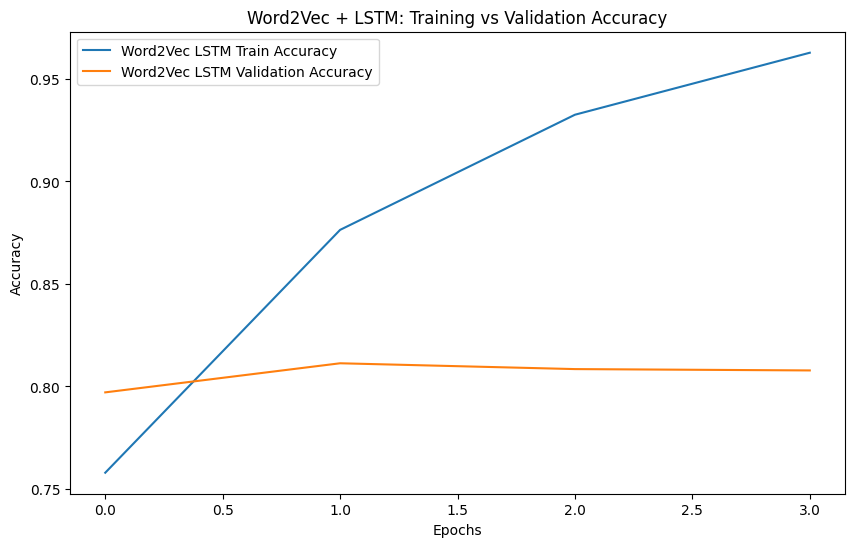

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history_rnn.history['accuracy'], label='RNN Train Accuracy')
plt.plot(history_rnn.history['val_accuracy'], label='RNN Validation Accuracy')
plt.title("Simple RNN: Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(history_lstm.history['accuracy'], label='LSTM Train Accuracy')
plt.plot(history_lstm.history['val_accuracy'], label='LSTM Validation Accuracy')
plt.title("LSTM: Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(history_word2vec.history['accuracy'], label='Word2Vec LSTM Train Accuracy')
plt.plot(history_word2vec.history['val_accuracy'], label='Word2Vec LSTM Validation Accuracy')
plt.title("Word2Vec + LSTM: Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## Plot Loss Curves

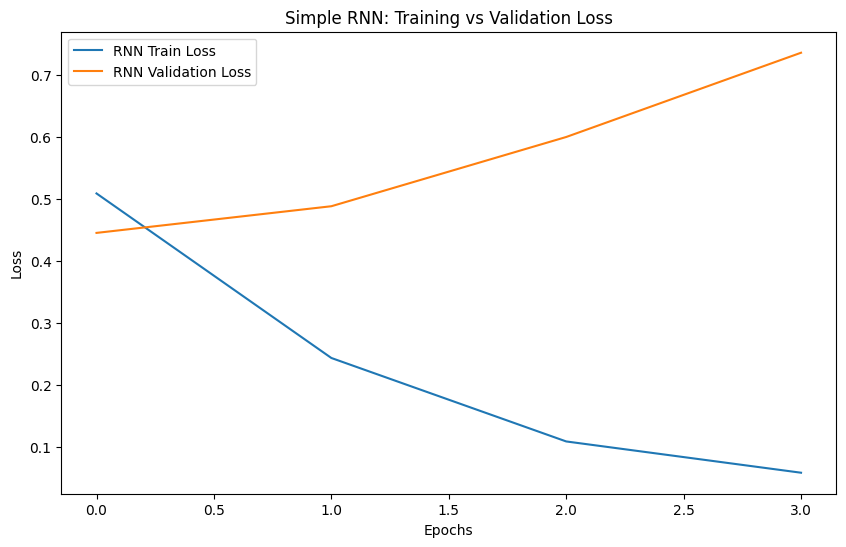

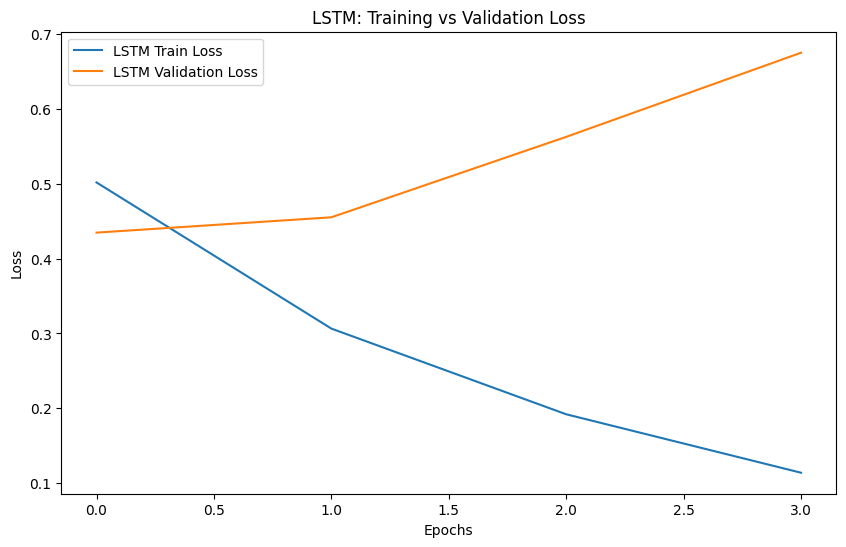

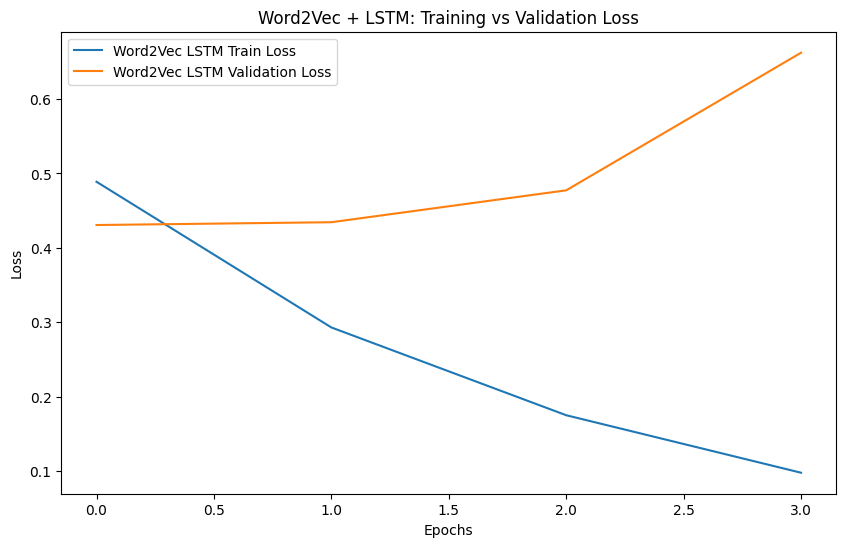

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history_rnn.history['loss'], label='RNN Train Loss')
plt.plot(history_rnn.history['val_loss'], label='RNN Validation Loss')
plt.title("Simple RNN: Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(history_lstm.history['loss'], label='LSTM Train Loss')
plt.plot(history_lstm.history['val_loss'], label='LSTM Validation Loss')
plt.title("LSTM: Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(history_word2vec.history['loss'], label='Word2Vec LSTM Train Loss')
plt.plot(history_word2vec.history['val_loss'], label='Word2Vec LSTM Validation Loss')
plt.title("Word2Vec + LSTM: Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

## Predictions

In [ ]:
rnn_pred = (simple_rnn_model.predict(X_test_padded) > 0.5).astype("int32")
lstm_pred = (lstm_model.predict(X_test_padded) > 0.5).astype("int32")
word2vec_pred = (word2vec_lstm_model.predict(X_test_padded) > 0.5).astype("int32")

179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


## Model Comparison Table

In [ ]:
comparison_table = pd.DataFrame({
    "Model": ["Simple RNN", "LSTM", "Word2Vec + LSTM"],
    "Test Accuracy": [rnn_eval_accuracy, lstm_eval_accuracy, word2vec_eval_accuracy],
    "Test Loss": [rnn_loss, lstm_loss, word2vec_loss],
    "Training Time (seconds)": [rnn_time, lstm_time, word2vec_time]
})

print("\nFinal Model Comparison Table:")
print(comparison_table)


Final Model Comparison Table:
             Model  Test Accuracy  Test Loss  Training Time (seconds)
0       Simple RNN       0.793326   0.456016               110.796866
1             LSTM       0.788435   0.438157               122.165782
2  Word2Vec + LSTM       0.800664   0.426599               145.180286


## Confusion Matrices

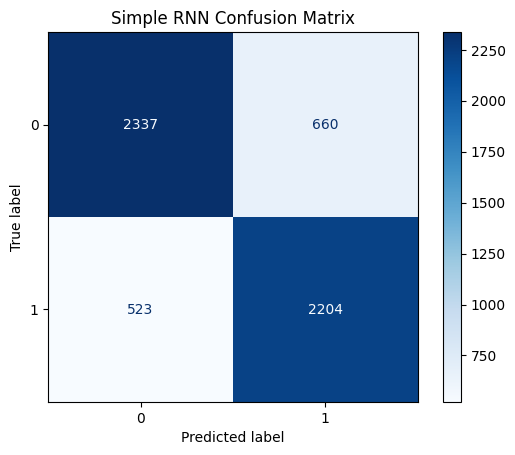

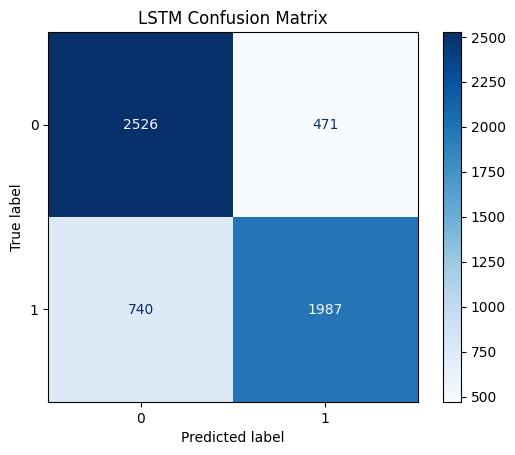

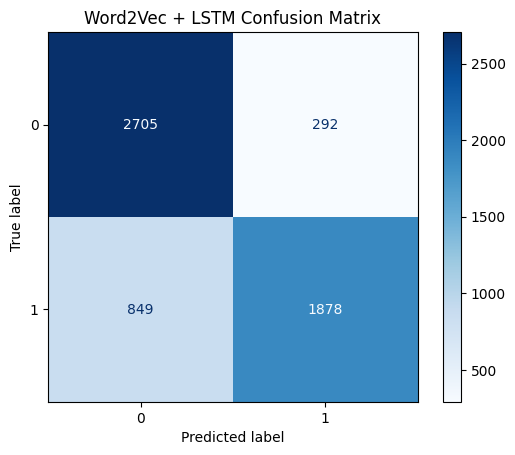

In [ ]:
cm_rnn = confusion_matrix(y_test, rnn_pred)
disp_rnn = ConfusionMatrixDisplay(confusion_matrix=cm_rnn)
disp_rnn.plot(cmap="Blues")
plt.title("Simple RNN Confusion Matrix")
plt.show()

cm_lstm = confusion_matrix(y_test, lstm_pred)
disp_lstm = ConfusionMatrixDisplay(confusion_matrix=cm_lstm)
disp_lstm.plot(cmap="Blues")
plt.title("LSTM Confusion Matrix")
plt.show()

cm_word2vec = confusion_matrix(y_test, word2vec_pred)
disp_word2vec = ConfusionMatrixDisplay(confusion_matrix=cm_word2vec)
disp_word2vec.plot(cmap="Blues")
plt.title("Word2Vec + LSTM Confusion Matrix")
plt.show()

## Classification Reports

In [ ]:
print("\nSimple RNN Classification Report:\n")
print(classification_report(y_test, rnn_pred))

print("\nLSTM Classification Report:\n")
print(classification_report(y_test, lstm_pred))

print("\nWord2Vec + LSTM Classification Report:\n")
print(classification_report(y_test, word2vec_pred))


Simple RNN Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.78      0.80      2997
           1       0.77      0.81      0.79      2727

    accuracy                           0.79      5724
   macro avg       0.79      0.79      0.79      5724
weighted avg       0.79      0.79      0.79      5724


LSTM Classification Report:

              precision    recall  f1-score   support

           0       0.77      0.84      0.81      2997
           1       0.81      0.73      0.77      2727

    accuracy                           0.79      5724
   macro avg       0.79      0.79      0.79      5724
weighted avg       0.79      0.79      0.79      5724


Word2Vec + LSTM Classification Report:

              precision    recall  f1-score   support

           0       0.76      0.90      0.83      2997
           1       0.87      0.69      0.77      2727

    accuracy                           0.80      5724
   macro avg       0.

# Error Analysis

## Misclassified Examples

In [ ]:
error_analysis_df = pd.DataFrame({
    "headline": X_test.values,
    "actual_label": y_test.values,
    "rnn_prediction": rnn_pred.flatten(),
    "lstm_prediction": lstm_pred.flatten(),
    "word2vec_prediction": word2vec_pred.flatten()
})

misclassified = error_analysis_df[
    error_analysis_df["actual_label"] != error_analysis_df["word2vec_prediction"]
]

print("\nNumber of Misclassified Examples:")
print(len(misclassified))

print("\nSample Misclassified Headlines:")
print(
    misclassified[
        ["headline", "actual_label", "word2vec_prediction"]
    ].head(3)
)


Number of Misclassified Examples:
1141

Sample Misclassified Headlines:
                                            headline  actual_label  \
2      group christie campaign deserter found forest             1   
4  democratic congressman protest trump environme...             1   
5         rex tillerson call report ouster laughable             0   

   word2vec_prediction  
2                    0  
4                    0  
5                    1  


## Model Complexity vs Performance

In [ ]:
complexity_table = pd.DataFrame({
    "Model": ["Simple RNN", "LSTM", "Word2Vec + LSTM"],
    "Complexity": [
        "Lowest complexity",
        "Medium complexity",
        "Higher complexity because it uses pretrained 300-dimensional Word2Vec embeddings"
    ],
    "Test Accuracy": [rnn_eval_accuracy, lstm_eval_accuracy, word2vec_eval_accuracy],
    "Test Loss": [rnn_loss, lstm_loss, word2vec_loss],
    "Training Time (seconds)": [rnn_time, lstm_time, word2vec_time]
})

print("\nModel Complexity vs Performance:")
print(complexity_table)


Model Complexity vs Performance:
             Model                                         Complexity  \
0       Simple RNN                                  Lowest complexity   
1             LSTM                                  Medium complexity   
2  Word2Vec + LSTM  Higher complexity because it uses pretrained 3...   

   Test Accuracy  Test Loss  Training Time (seconds)  
0       0.793326   0.456016               110.796866  
1       0.788435   0.438157               122.165782  
2       0.800664   0.426599               145.180286  


## Possible Error Reasons and Improvements

###Possible Reasons for Errors


- Sarcasm is difficult to detect because it often depends on hidden meaning and context.


- Some real headlines look sarcastic, which confuses the model.


- Some sarcastic headlines are very short and provide limited information.


- The model may not fully understand emotions, tone, or humor in text.


- Unknown or rare words may reduce prediction accuracy.


- The models showed signs of overfitting because training accuracy became much higher than validation accuracy.

### Suggested Improvements
- Use a larger and more diverse sarcasm dataset.

- Apply hyperparameter tuning such as changing learning rate, batch size, and number of LSTM units.

- Use Bidirectional LSTM for better understanding of sentence context.

- Use transformer-based models like BERT for improved contextual understanding.

- Apply stronger regularization techniques to reduce overfitting.

- Increase training data preprocessing and text normalization.

- Experiment with different pretrained embeddings such as GloVe or FastText.

# GUI for Real-Time Prediction

## Gradio Interface

In [ ]:
import gradio as gr

accuracies = {
    "Simple RNN": rnn_eval_accuracy,
    "LSTM": lstm_eval_accuracy,
    "Word2Vec + LSTM": word2vec_eval_accuracy
}

best_model_name = max(accuracies, key=accuracies.get)

if best_model_name == "Simple RNN":
    best_model = simple_rnn_model
elif best_model_name == "LSTM":
    best_model = lstm_model
else:
    best_model = word2vec_lstm_model

print("Best Model Used for GUI:", best_model_name)

def predict_sarcasm(user_input):
    cleaned_text = clean_text(user_input)

    sequence = tokenizer.texts_to_sequences([cleaned_text])

    padded_sequence = pad_sequences(
        sequence,
        maxlen=max_length,
        padding='post',
        truncating='post'
    )

    prediction = best_model.predict(padded_sequence)[0][0]

    if prediction >= 0.5:
        result = "Sarcastic"
        confidence = prediction
    else:
        result = "Not Sarcastic"
        confidence = 1 - prediction

    return f"Prediction: {result}\nConfidence Score: {confidence:.4f}"

interface = gr.Interface(
    fn=predict_sarcasm,
    inputs=gr.Textbox(
        lines=3,
        placeholder="Enter a headline here..."
    ),
    outputs="text",
    title="Real-Time Sarcasm Detection",
    description="Enter a headline, and the model will predict whether it is sarcastic or not."
)

interface.launch(share=True)

Best Model Used for GUI: Word2Vec + LSTM
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e59a7220f481b46052.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
